In [7]:
from langgraph.graph import StateGraph, MessagesState, START, END


def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}


graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='96a89621-1535-4efc-9701-db28489a3d36'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='9bc4d5c9-df59-4f1d-ab95-414e90b36cfc', tool_calls=[], invalid_tool_calls=[])]}

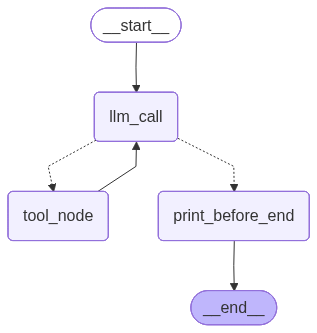

[chain/start] [chain:LangGraph] Entering Chain run with input:
[inputs]
[chain/start] [chain:LangGraph > chain:llm_call] Entering Chain run with input:
[inputs]
[llm/start] [chain:LangGraph > chain:llm_call > llm:ChatOpenAI] Entering LLM run with input:
{
  "prompts": [
    "System: You are a helpful assistant tasked with performing arithmetic on a set of inputs.\nHuman: multiply 3 and 4.then add 5"
  ]
}
[llm/end] [chain:LangGraph > chain:llm_call > llm:ChatOpenAI] [1.93s] Exiting LLM run with output:
{
  "generations": [
    [
      {
        "text": "",
        "generation_info": {
          "finish_reason": "tool_calls",
          "logprobs": null
        },
        "type": "ChatGeneration",
        "message": {
          "lc": 1,
          "type": "constructor",
          "id": [
            "langchain",
            "schema",
            "messages",
            "AIMessage"
          ],
          "kwargs": {
            "content": "",
            "additional_kwargs": {
            

In [19]:

from IPython.core.display import Image
from operator import add
from typing_extensions import Annotated
from langchain_core.messages import AnyMessage, SystemMessage, ToolMessage, HumanMessage
from langchain_core.tools import tool
from typing import TypedDict, Literal
from utils.std_model import base_model
from langgraph.graph import StateGraph, START, END

llm = base_model()


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add]
    llm_calls: int


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""
    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.",
                    )
                ] + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }


def tool_node(state: dict):
    """Performs the tool call"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {
        "messages": result,
    }


def should_continue(state: MessagesState) -> Literal["tool_node", "print_before_end"]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""
    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return "print_before_end"


def print_before_end(state):
    print('llm_calls', state['llm_calls'])
    # 由于消息数据是add的。所以不能返回state
    return {}  # 不修改state，只打印


messagesState_graph_builder = StateGraph(MessagesState)
messagesState_graph_builder.add_node("llm_call", llm_call)
messagesState_graph_builder.add_node("tool_node", tool_node)
messagesState_graph_builder.add_node("print_before_end", print_before_end)

messagesState_graph_builder.add_edge(START, "llm_call")
messagesState_graph_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", "print_before_end"])
messagesState_graph_builder.add_edge("tool_node", "llm_call")
messagesState_graph_builder.add_edge("print_before_end", END)
messagesState_graph = messagesState_graph_builder.compile()

display(Image(messagesState_graph.get_graph(xray=True).draw_mermaid_png()))
req_messages = [HumanMessage(content="multiply 3 and 4.then add 5")]
resp_messages = messagesState_graph.invoke({"messages": req_messages})
for m in resp_messages["messages"]:
    m.pretty_print()


In [1]:
from langgraph.graph import add_messages
from langchain_core.messages import BaseMessage, ToolCall, SystemMessage, ToolMessage, HumanMessage
from langgraph.func import task, entrypoint
from utils.std_model import base_model
from langchain_core.tools import tool

llm = base_model()


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)


@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return llm_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )


@task
def call_tool(tool_call: ToolCall):
    """Performs the tool call"""
    tool = tools_by_name[tool_call["name"]]
    return tool.invoke(tool_call)


@entrypoint()
def agent(messages: list[BaseMessage]):
    model_response = call_llm(messages).result()

    while True:
        if not model_response.tool_calls:
            break

        # Execute tools
        tool_result_futures = [
            call_tool(tool_call) for tool_call in model_response.tool_calls
        ]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [model_response, *tool_results])
        model_response = call_llm(messages).result()

    messages = add_messages(messages, model_response)
    return messages


# Invoke
messages = [HumanMessage(content="Add 3 and 4.then add 5")]
for chunk in agent.stream(messages, stream_mode="updates"):
    print(chunk)
    print("\n")

{'call_llm': AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 484, 'total_tokens': 570, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 26, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': None, 'id': 'chatcmpl-1736689d-3737-959c-bde9-38933c2b1931', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e440c-14b4-78a2-9bbf-3cebf76c01d9-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_f1ff6110bf714cfb88428d84', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 484, 'output_tokens': 86, 'total_tokens': 570, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 26}})}


{'call_tool': ToolMessage(content='7', name='add',